# Phase 2 XGBoost Model

This notebook trains the third phase-2 model: an XGBoost regressor predicting next-year median sale price from the selected phase-2 feature set.

It uses the same modeling setup as the Random Forest and Linear Regression notebooks:

- Train/CV pool: 2012-2022 rows
- Final holdout: 2023 rows, targeting 2024 median sale price
- Target used for training: `log(next_year_annual_median_sale_price / annual_median_sale_price)`

The notebook writes metrics, predictions, feature-importance files, and quick visuals to `outputs/phase2-models/xgboost/`.

In [1]:
from pathlib import Path
import json
import os

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'outputs' / 'phase2-models' / 'model-data').exists()
)

CACHE_DIR = PROJECT_ROOT / 'outputs' / 'cache'
os.environ.setdefault('MPLCONFIGDIR', str(CACHE_DIR / 'matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(CACHE_DIR / 'xdg'))
(CACHE_DIR / 'matplotlib').mkdir(parents=True, exist_ok=True)
(CACHE_DIR / 'xdg').mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

PLOT_STYLE = {
    'figure.dpi': 120,
    'savefig.dpi': 240,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 18,
}
plt.rcParams.update(PLOT_STYLE)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
import xgboost as xgb

RANDOM_STATE = 42
MODEL_DATA_DIR = PROJECT_ROOT / 'outputs' / 'phase2-models' / 'model-data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'phase2-models' / 'xgboost'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')
print(f'xgboost version: {xgb.__version__}')

PROJECT_ROOT: /Users/charlesgao/Desktop/spring2026/stats170B/project
OUTPUT_DIR: /Users/charlesgao/Desktop/spring2026/stats170B/project/outputs/phase2-models/xgboost
xgboost version: 3.2.0


## Load Selected Model Data

In [2]:
train = pd.read_csv(MODEL_DATA_DIR / 'phase2_selected_train_2012_2022.csv', dtype={'zcta5': str}, low_memory=False)
test = pd.read_csv(MODEL_DATA_DIR / 'phase2_selected_test_2023.csv', dtype={'zcta5': str}, low_memory=False)
feature_schema = pd.read_csv(MODEL_DATA_DIR / 'phase2_selected_feature_schema.csv')
feature_config = json.loads((MODEL_DATA_DIR / 'phase2_selected_features.json').read_text())
cv_folds = pd.read_csv(MODEL_DATA_DIR / 'phase2_time_blocked_cv_folds.csv')

TARGET = 'y_next_year_median_sale_price_log_change'
TARGET_DOLLARS = 'y_next_year_median_sale_price'
CURRENT_PRICE = 'annual_median_sale_price'
FEATURES = feature_config['feature_sets']['all_selected_features']
NUMERIC_FEATURES = feature_config['preprocessing']['numeric']
CATEGORICAL_FEATURES = feature_config['preprocessing']['categorical']
BOOLEAN_FEATURES = feature_config['preprocessing']['boolean']

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'Selected features: {len(FEATURES)}')
print(f'Numeric: {len(NUMERIC_FEATURES)}, categorical: {len(CATEGORICAL_FEATURES)}, boolean: {len(BOOLEAN_FEATURES)}')
print(f'Train years: {train.year.min()}-{train.year.max()}')
print(f'Test years: {sorted(test.year.unique())}')

Train shape: (12530, 59)
Test shape: (1138, 59)
Selected features: 54
Numeric: 44, categorical: 3, boolean: 7
Train years: 2012-2022
Test years: [np.int64(2023)]


## Preprocessing And Model Definition

The model uses the same raw selected features as the other Phase 2 notebooks. Numeric features are median-imputed; categorical and boolean features are imputed and one-hot encoded. XGBoost then fits boosted regression trees on the transformed feature matrix.

In [3]:
XGB_PARAMS = {
    'n_estimators': 450,
    'learning_rate': 0.020,
    'max_depth': 4,
    'min_child_weight': 20,
    'subsample': 0.75,
    'colsample_bytree': 0.75,
    'reg_alpha': 0.5,
    'reg_lambda': 40.0,
    'gamma': 0.02,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',
    'importance_type': 'gain',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': 0,
}


def make_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    boolean_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ('numeric', numeric_pipeline, NUMERIC_FEATURES),
            ('categorical', categorical_pipeline, CATEGORICAL_FEATURES),
            ('boolean', boolean_pipeline, BOOLEAN_FEATURES),
        ],
        remainder='drop',
        verbose_feature_names_out=True,
    )


def make_xgboost_pipeline() -> Pipeline:
    return Pipeline([
        ('preprocess', make_preprocessor()),
        ('model', XGBRegressor(**XGB_PARAMS)),
    ])


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_predictions(y_true_log_change, y_pred_log_change, current_price, y_true_dollars) -> dict[str, float]:
    y_true_dollars = pd.Series(y_true_dollars).astype(float)
    y_pred_dollars = pd.Series(current_price).astype(float) * np.exp(y_pred_log_change)
    y_true_growth_pct = np.expm1(y_true_log_change) * 100.0
    y_pred_growth_pct = np.expm1(y_pred_log_change) * 100.0
    return {
        'mae_log_change': mean_absolute_error(y_true_log_change, y_pred_log_change),
        'rmse_log_change': rmse(y_true_log_change, y_pred_log_change),
        'r2_log_change': r2_score(y_true_log_change, y_pred_log_change),
        'mae_growth_pct_points': mean_absolute_error(y_true_growth_pct, y_pred_growth_pct),
        'rmse_growth_pct_points': rmse(y_true_growth_pct, y_pred_growth_pct),
        'r2_growth_pct': r2_score(y_true_growth_pct, y_pred_growth_pct),
        'mae_dollars': mean_absolute_error(y_true_dollars, y_pred_dollars),
        'rmse_dollars': rmse(y_true_dollars, y_pred_dollars),
        'r2_dollars': r2_score(y_true_dollars, y_pred_dollars),
    }


def feature_group_lookup() -> dict[str, str]:
    selected = feature_schema[feature_schema['selected']].copy()
    return dict(zip(selected['feature'], selected['source_group']))


def original_feature_from_transformed(transformed_name: str) -> str:
    _, raw_name = transformed_name.split('__', 1)
    for feature in sorted(FEATURES, key=len, reverse=True):
        if raw_name == feature or raw_name.startswith(f'{feature}_'):
            return feature
    return raw_name


group_lookup = feature_group_lookup()
XGB_PARAMS

{'n_estimators': 450,
 'learning_rate': 0.02,
 'max_depth': 4,
 'min_child_weight': 20,
 'subsample': 0.75,
 'colsample_bytree': 0.75,
 'reg_alpha': 0.5,
 'reg_lambda': 40.0,
 'gamma': 0.02,
 'objective': 'reg:squarederror',
 'eval_metric': 'rmse',
 'tree_method': 'hist',
 'importance_type': 'gain',
 'random_state': 42,
 'n_jobs': -1,
 'verbosity': 0}

## Time-Blocked Cross Validation

Each fold trains on past years and validates on the next held-out year.

In [4]:
cv_rows = []

for fold in cv_folds.itertuples(index=False):
    train_fold = train[train['year'].lt(fold.validation_year)].copy()
    validation_fold = train[train['year'].eq(fold.validation_year)].copy()

    model = make_xgboost_pipeline()
    model.fit(train_fold[FEATURES], train_fold[TARGET])
    pred_log_change = model.predict(validation_fold[FEATURES])
    metrics = evaluate_predictions(
            validation_fold[TARGET],
            pred_log_change,
            validation_fold[CURRENT_PRICE],
            validation_fold[TARGET_DOLLARS],
        )
    metrics.update({
        'fold': fold.fold,
        'validation_year': fold.validation_year,
        'train_rows': len(train_fold),
        'validation_rows': len(validation_fold),
    })
    cv_rows.append(metrics)

cv_metrics = pd.DataFrame(cv_rows)
metric_cols = ['fold', 'validation_year', 'train_rows', 'validation_rows', 'mae_dollars', 'rmse_dollars', 'r2_dollars', 'mae_log_change', 'rmse_log_change', 'r2_log_change', 'mae_growth_pct_points', 'rmse_growth_pct_points', 'r2_growth_pct']
cv_metrics = cv_metrics[metric_cols]
cv_metrics.to_csv(OUTPUT_DIR / 'xgboost_cv_metrics.csv', index=False)
cv_metrics

,fold,validation_year,train_rows,validation_rows,mae_dollars,rmse_dollars,r2_dollars,mae_log_change,rmse_log_change,r2_log_change,mae_growth_pct_points,rmse_growth_pct_points,r2_growth_pct
0,1,2017,5590,1146,36842.305197,96024.578383,0.966901,0.050269,0.093089,0.093033,5.308382,9.157084,0.114387
1,2,2018,6736,1155,52123.963109,94951.159880,0.966511,0.068182,0.098095,-0.292763,7.121695,10.977640,-0.201712
2,3,2019,7891,1159,55256.557797,123787.429566,0.945783,0.077515,0.121245,-0.157434,8.264015,12.021179,-0.273410
3,4,2020,9050,1178,77643.658191,126557.439862,0.958778,0.093766,0.117289,-0.589707,10.776815,13.836401,-0.603172
4,5,2021,10228,1160,76276.048657,113943.473682,0.968017,0.086627,0.113290,-0.526530,9.500463,12.002901,-0.547178
5,6,2022,11388,1142,86696.797782,125197.421208,0.960525,0.097537,0.118947,-0.918327,9.933259,12.012122,-0.879282


In [5]:
cv_summary = cv_metrics.drop(columns=['fold', 'validation_year']).agg(['mean', 'std']).T.reset_index()
cv_summary = cv_summary.rename(columns={'index': 'metric'})
cv_summary.to_csv(OUTPUT_DIR / 'xgboost_cv_summary.csv', index=False)
cv_summary

,metric,mean,std
0,train_rows,8480.500000,2171.516682
1,validation_rows,1156.666667,12.675436
2,mae_dollars,64139.888456,19010.031126
3,rmse_dollars,113410.250430,14579.134235
4,r2_dollars,0.961086,0.008380
5,mae_log_change,0.078983,0.017689
6,rmse_log_change,0.110326,0.011811
7,r2_log_change,-0.398621,0.356109
8,mae_growth_pct_points,8.484105,2.018879
9,rmse_growth_pct_points,11.667888,1.538738


## Final Train On 2012-2022, Test On 2023

In [6]:
final_model = make_xgboost_pipeline()
final_model.fit(train[FEATURES], train[TARGET])

test_pred_log_change = final_model.predict(test[FEATURES])
test_metrics = evaluate_predictions(
    test[TARGET],
    test_pred_log_change,
    test[CURRENT_PRICE],
    test[TARGET_DOLLARS],
)
test_metrics = pd.DataFrame([{**test_metrics, 'train_years': '2012-2022', 'test_year': 2023, 'target_year': 2024}])
test_metrics.to_csv(OUTPUT_DIR / 'xgboost_2023_holdout_metrics.csv', index=False)
test_metrics

,mae_log_change,rmse_log_change,r2_log_change,mae_growth_pct_points,rmse_growth_pct_points,r2_growth_pct,mae_dollars,rmse_dollars,r2_dollars,train_years,test_year,target_year
0,0.069331,0.095882,-0.209636,7.095848,9.711045,-0.26784,70737.285894,132205.928814,0.963498,2012-2022,2023,2024


In [7]:
holdout_predictions = test[['zcta5', 'year', CURRENT_PRICE, TARGET_DOLLARS, TARGET]].copy()
holdout_predictions['pred_log_change_next_year_median_sale_price'] = test_pred_log_change
holdout_predictions['pred_next_year_median_sale_price'] = holdout_predictions[CURRENT_PRICE] * np.exp(test_pred_log_change)
holdout_predictions['absolute_error_dollars'] = (
    holdout_predictions['pred_next_year_median_sale_price'] - holdout_predictions[TARGET_DOLLARS]
).abs()
holdout_predictions['error_dollars'] = (
    holdout_predictions['pred_next_year_median_sale_price'] - holdout_predictions[TARGET_DOLLARS]
)
holdout_predictions.to_csv(OUTPUT_DIR / 'xgboost_2023_holdout_predictions.csv', index=False)
holdout_predictions.sort_values('absolute_error_dollars', ascending=False).head(20)

,zcta5,year,annual_median_sale_price,y_next_year_median_sale_price,y_next_year_median_sale_price_log_change,pred_log_change_next_year_median_sale_price,pred_next_year_median_sale_price,absolute_error_dollars,error_dollars
460,92657,2023,4.311849e+06,5.791146e+06,0.294963,-0.003714,4.295864e+06,1.495282e+06,-1.495282e+06
965,95441,2023,2.381911e+06,9.333824e+05,-0.936844,-0.031684,2.307627e+06,1.374244e+06,1.374244e+06
462,92662,2023,3.581920e+06,4.517883e+06,0.232145,0.011767,3.624319e+06,8.935644e+05,-8.935644e+05
55,90210,2023,5.291482e+06,4.225989e+06,-0.224845,-0.034698,5.111027e+06,8.850378e+05,8.850378e+05
731,94305,2023,2.274457e+06,3.103385e+06,0.310752,-0.016409,2.237441e+06,8.659441e+05,-8.659441e+05
52,90077,2023,2.505886e+06,3.235394e+06,0.255508,-0.037640,2.413317e+06,8.220772e+05,-8.220772e+05
692,94028,2023,3.847172e+06,4.324725e+06,0.117010,-0.052580,3.650115e+06,6.746103e+05,-6.746103e+05
125,90743,2023,3.007143e+06,2.245000e+06,-0.292285,-0.032991,2.909552e+06,6.645515e+05,6.645515e+05
729,94301,2023,3.278978e+06,3.818893e+06,0.152429,-0.035697,3.163993e+06,6.548997e+05,-6.548997e+05
289,92067,2023,4.545650e+06,5.068633e+06,0.108900,-0.014158,4.481744e+06,5.868881e+05,-5.868881e+05


## XGBoost Gain Feature Importance

This is XGBoost's built-in gain importance after preprocessing. It is useful for model interpretation, but permutation importance below is the stronger holdout-based importance view.

In [8]:
transformed_feature_names = final_model.named_steps['preprocess'].get_feature_names_out()
gain_importance = pd.DataFrame({
    'transformed_feature': transformed_feature_names,
    'importance': final_model.named_steps['model'].feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

gain_importance['feature'] = gain_importance['transformed_feature'].map(original_feature_from_transformed)
gain_importance['source_group'] = gain_importance['feature'].map(group_lookup).fillna('unknown')
gain_importance.to_csv(OUTPUT_DIR / 'xgboost_gain_importance_transformed.csv', index=False)

gain_feature_importance = (
    gain_importance.groupby(['feature', 'source_group'], as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
gain_feature_importance.to_csv(OUTPUT_DIR / 'xgboost_gain_importance_features.csv', index=False)
gain_feature_importance.head(25)

,feature,source_group,importance
0,assessment_type,school_quality,0.290925
1,foreign_born_noncitizen_derived,demographics,0.117085
2,parent_metro_region,listings,0.092158
3,minimum_wage_for_model_annual_avg,minimum_wage,0.054478
4,annual_median_sale_price,listings,0.024945
5,total_students_tested_unreliable,school_quality,0.016496
6,log_median_household_income,demographics,0.015543
7,annual_months_of_supply_est,listings,0.014661
8,education_bachelors_or_higher_share,demographics,0.014643
9,annual_median_ppsf,listings,0.013350


## Permutation Feature Importance On 2023 Holdout

This measures how much holdout performance worsens when each raw feature is shuffled. Higher values mean the feature contributed more to the final model's 2023 predictions.

In [9]:
permutation = permutation_importance(
    final_model,
    test[FEATURES],
    test[TARGET],
    scoring='neg_mean_absolute_error',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance_mean_log_mae': permutation.importances_mean,
    'importance_std_log_mae': permutation.importances_std,
})
permutation_importance_df['source_group'] = permutation_importance_df['feature'].map(group_lookup).fillna('unknown')
permutation_importance_df = permutation_importance_df.sort_values('importance_mean_log_mae', ascending=False).reset_index(drop=True)
permutation_importance_df.to_csv(OUTPUT_DIR / 'xgboost_permutation_importance.csv', index=False)
permutation_importance_df.head(25)

,feature,importance_mean_log_mae,importance_std_log_mae,source_group
0,annual_off_market_in_two_weeks,0.001797,2.296222e-04,listings
1,annual_median_sale_price,0.001563,2.188100e-04,listings
2,annual_months_of_supply_est,0.000987,1.088163e-04,listings
3,annual_homes_sold,0.000628,9.153258e-05,listings
4,parent_metro_region,0.000503,7.088030e-05,listings
5,log_median_household_income,0.000459,5.928289e-05,demographics
6,crime_property_est_per_1k,0.000259,8.147812e-05,crime
7,annual_sold_above_list,0.000153,2.747426e-05,listings
8,annual_median_ppsf,0.000150,6.169312e-05,listings
9,education_some_college_or_associates_share,0.000150,2.063772e-05,demographics


In [10]:
group_permutation_importance = (
    permutation_importance_df.groupby('source_group', as_index=False)
    .agg(
        importance_sum_log_mae=('importance_mean_log_mae', 'sum'),
        importance_mean_log_mae=('importance_mean_log_mae', 'mean'),
        features=('feature', 'count'),
    )
    .sort_values('importance_sum_log_mae', ascending=False)
    .reset_index(drop=True)
)
group_permutation_importance.to_csv(OUTPUT_DIR / 'xgboost_permutation_importance_by_group.csv', index=False)
group_permutation_importance

,source_group,importance_sum_log_mae,importance_mean_log_mae,features
0,listings,0.005279,4.399570e-04,12
1,crime,0.000394,1.971148e-04,2
2,other,0.000033,3.264418e-05,1
3,amenities,0.000004,8.104583e-07,5
4,minimum_wage,0.000000,0.000000e+00,3
5,school_quality,-0.000020,-3.311918e-06,6
6,demographics,-0.000585,-2.341511e-05,25


## Quick Visuals

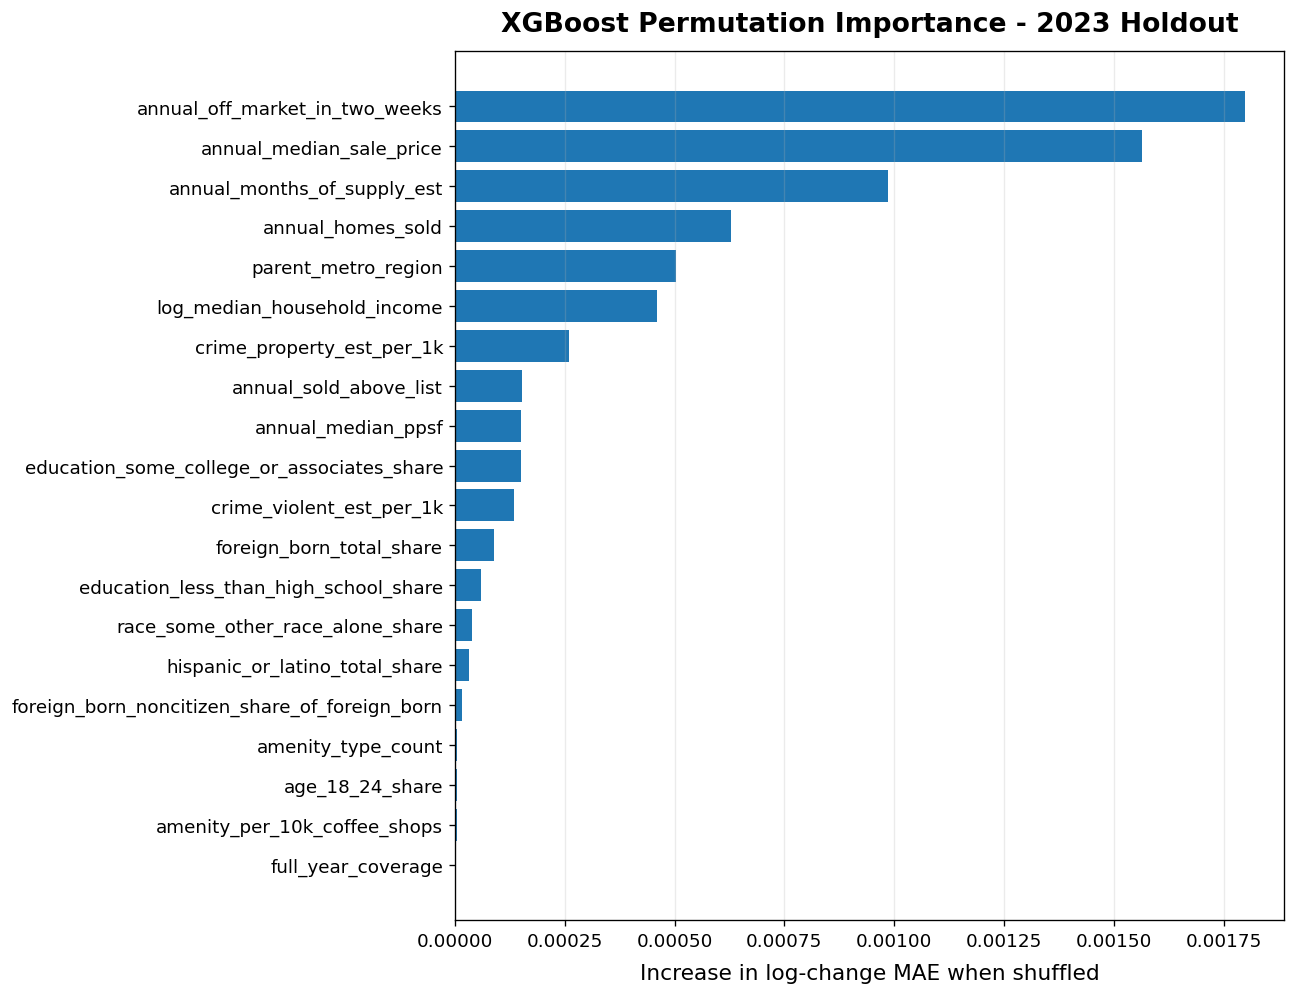

In [11]:
top_n = 20
plot_df = permutation_importance_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 8.5))
ax.barh(plot_df['feature'], plot_df['importance_mean_log_mae'])
ax.set_title('XGBoost Permutation Importance - 2023 Holdout', pad=12, fontweight='semibold')
ax.set_xlabel('Increase in log-change MAE when shuffled', labelpad=8)
ax.grid(axis='x', alpha=0.25)
ax.tick_params(axis='both', labelsize=11)
fig.tight_layout(pad=1.2)
fig.savefig(OUTPUT_DIR / 'xgboost_top20_permutation_importance.png', dpi=240)
plt.show()

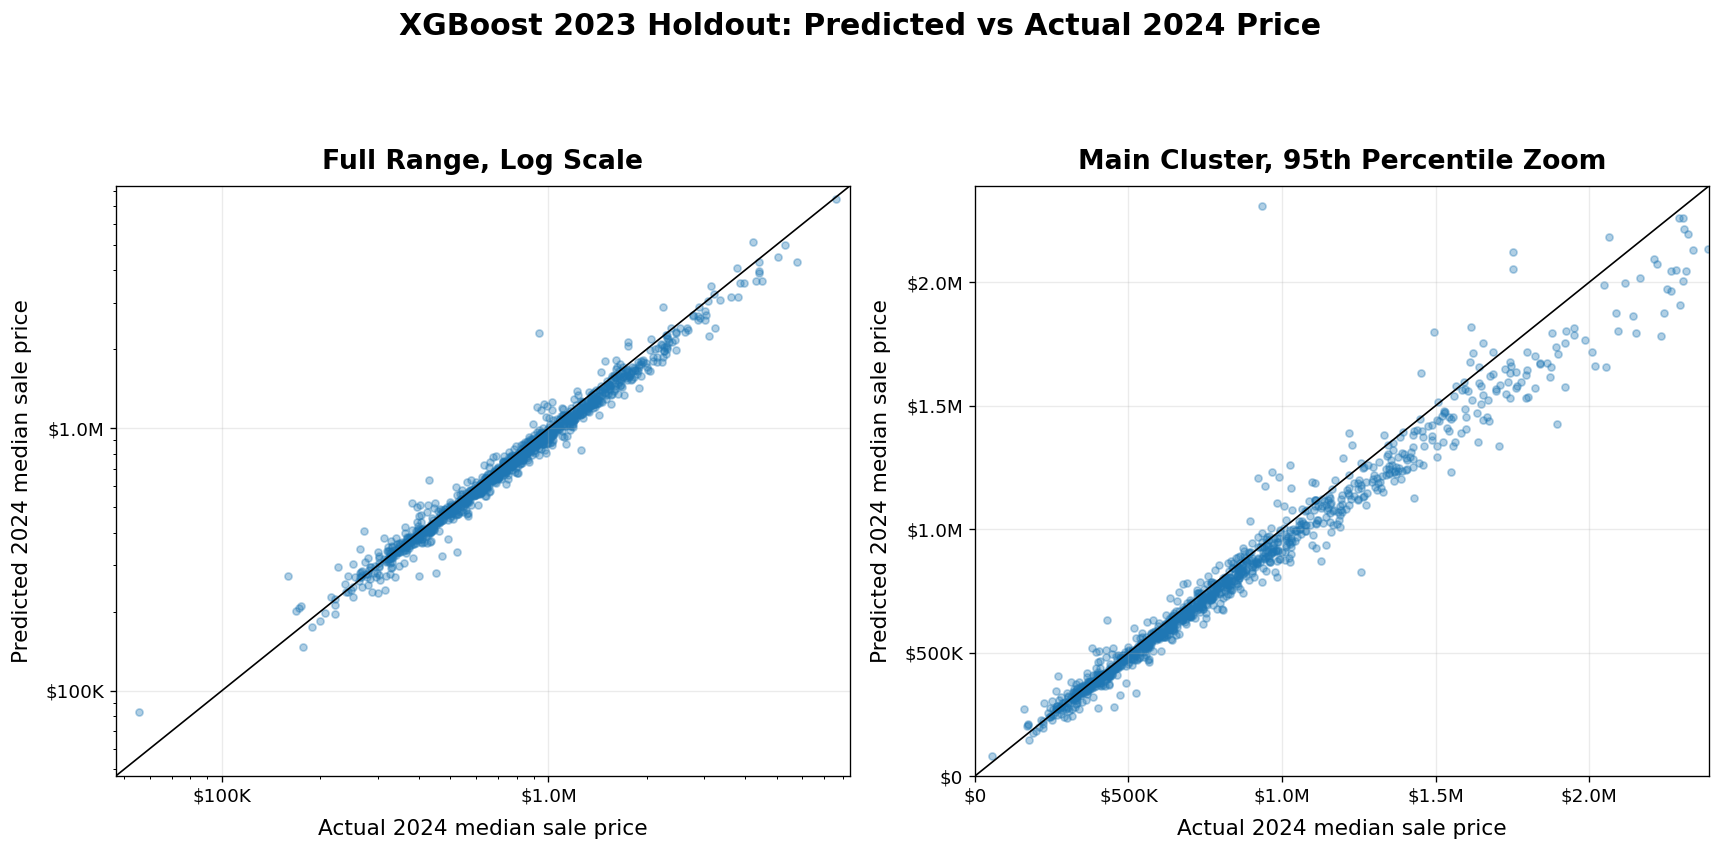

In [12]:
def compact_dollars(value, _):
    if value >= 1_000_000:
        return f'${value / 1_000_000:.1f}M'
    if value >= 1_000:
        return f'${value / 1_000:.0f}K'
    return f'${value:.0f}'

actual_price = holdout_predictions[TARGET_DOLLARS]
predicted_price = holdout_predictions['pred_next_year_median_sale_price']
dollar_formatter = FuncFormatter(compact_dollars)
positive_mask = actual_price.gt(0) & predicted_price.gt(0)
full_lims = [
    min(actual_price[positive_mask].min(), predicted_price[positive_mask].min()) * 0.85,
    max(actual_price[positive_mask].max(), predicted_price[positive_mask].max()) * 1.10,
]
zoom_limit = max(actual_price.quantile(0.95), predicted_price.quantile(0.95)) * 1.10

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.8))
axes[0].scatter(actual_price, predicted_price, alpha=0.35, s=18)
axes[0].plot(full_lims, full_lims, color='black', linewidth=1)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(full_lims)
axes[0].set_ylim(full_lims)
axes[0].set_title('Full Range, Log Scale', pad=10, fontweight='semibold')

axes[1].scatter(actual_price, predicted_price, alpha=0.35, s=18)
axes[1].plot([0, zoom_limit], [0, zoom_limit], color='black', linewidth=1)
axes[1].set_xlim(0, zoom_limit)
axes[1].set_ylim(0, zoom_limit)
axes[1].set_title('Main Cluster, 95th Percentile Zoom', pad=10, fontweight='semibold')

for ax in axes:
    ax.set_xlabel('Actual 2024 median sale price', labelpad=8)
    ax.set_ylabel('Predicted 2024 median sale price', labelpad=8)
    ax.xaxis.set_major_formatter(dollar_formatter)
    ax.yaxis.set_major_formatter(dollar_formatter)
    ax.grid(alpha=0.25)
    ax.tick_params(axis='both', labelsize=11)

fig.suptitle('XGBoost 2023 Holdout: Predicted vs Actual 2024 Price', y=1.04, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(OUTPUT_DIR / 'xgboost_2023_predicted_vs_actual.png', dpi=240, bbox_inches='tight')
plt.show()

## Output Files

After running all cells, the key files are:

- `xgboost_cv_metrics.csv`
- `xgboost_cv_summary.csv`
- `xgboost_2023_holdout_metrics.csv`
- `xgboost_2023_holdout_predictions.csv`
- `xgboost_gain_importance_features.csv`
- `xgboost_permutation_importance.csv`
- `xgboost_permutation_importance_by_group.csv`
- `xgboost_top20_permutation_importance.png`
- `xgboost_2023_predicted_vs_actual.png`